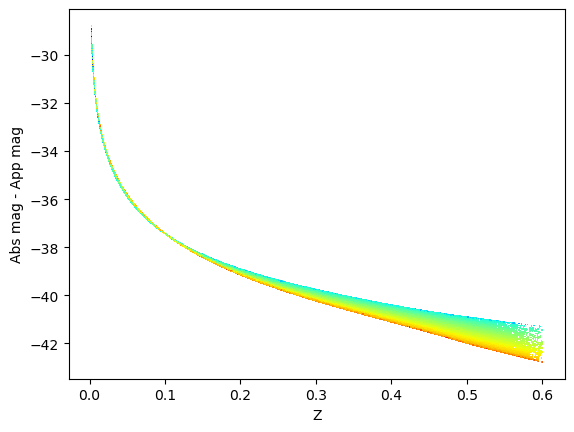

South sample size: 253033
North sample size: 114626
<Table length=367659>
       name           mean        std        min         max    
----------------- ----------- ----------- ---------- -----------
         TARGETID 5.27143e+06 3.00815e+06        132 1.04801e+07
           TILEID     23078.9     1827.33      20000       27852
  ABSMAG_RP1_ORIG    -20.2119      1.2038   -23.4295    -10.8985
REST_GMR_0P1_ORIG    0.721786    0.236318  -0.523583      1.6641
          gmr_obs    0.977848    0.392206  -0.502557     2.35777
              DEC     22.2941     23.1511   -19.2858      79.127
               RA     184.718     92.1816 0.00169094     359.996
                Z    0.205399   0.0977373 0.00222993    0.599254
            NTILE     2.41489      0.9172          1           5
              reg          --          --         --          --
 FRAC_TLOBS_TILES    0.985209   0.0265798        0.6           1
           WEIGHT     1.21089    0.665949          1          54
     WEIGHT_ZFAI

In [1]:
import catalogue_analysis as ca
import redshift_weights as rw
import kcorrections as k
import numpy as np
from astropy.table import join,Table,Column,vstack,setdiff
from astropy.io import fits
from kcorrections  import DESI_KCorrection #Needed to access the model k-corections
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=100, Om0=0.313, Tcmb0=2.725)   #Standard Planck Cosmology in Mpc/h units  #Dangerous as needs to be consistent with call in catalogue_analysis.py
import matplotlib.pyplot as plt

fsffile='./data/fastspec-iron-main-bright.fits' #fsf file used for k-corrections

# Specify regions to loop over
regions=('S','N')
fresh_kcorr = False  # whether to recompute k-correction

catalogue='/global/cfs/cdirs/desi/survey/catalogs/DA2/mocks/SecondGenMocks/AbacusSummitBGS_v2/altmtl0/loa-v1/mock0/LSScats/BGS_BRIGHT_clustering.dat.fits'
datall=Table.read(catalogue)

#Sanity check that apparent and absolute magnitudes are related.
plt.scatter(datall['Z'],datall['R_MAG_ABS']-datall['R_MAG_APP'],marker=',',lw=0,s=1.0,c=datall['G_R_REST'],cmap='jet')
plt.xlabel('Z')
plt.ylabel('Abs mag - App mag')
plt.show()

datall.rename_column('PHOTSYS', 'reg')
datall.rename_column('R_MAG_APP', 'rmag')
datall.rename_column('R_MAG_ABS','ABSMAG_RP1_ORIG')
datall.rename_column('G_R_OBS','gmr_obs') 
datall.rename_column('G_R_REST','REST_GMR_0P1_ORIG') 



#Random sample and apply all cuts from the start for a quick run through
Sel=ca.selection('N')# import North selection cuts  
smaskN= (datall['Z'] > Sel['zmin']) & (datall['Z'] < Sel['zmax']) & (np.random.rand(datall['Z'].size)<Sel['f_ran'])\
& (datall['rmag'] < Sel['faint'])  & (datall['rmag'] > Sel['bright']) & (datall['reg']=='N') 
Sel=ca.selection('S') # import South selection cuts    
smaskS= (datall['Z'] > Sel['zmin']) & (datall['Z'] < Sel['zmax']) &(np.random.rand(datall['Z'].size)<Sel['f_ran']) \
& (datall['rmag'] < Sel['faint'])  & (datall['rmag'] > Sel['bright']) & (datall['reg']=='S')
smask= np.logical_or(smaskN,smaskS) #True for objects making cuts in North or South
dat=datall[smask]    
print('South sample size:',smaskS.sum())
print('North sample size:',smaskN.sum())





#Placeholders for quantities to be estimated from the observed quantities
dat.add_column(Column(name='ABSMAG_RP1', data=np.zeros(dat["Z"].size)))
dat.add_column(Column(name='REST_GMR_0P1', data=np.zeros(dat["Z"].size)))

dat.info('stats')

for reg in regions:
    mask=(dat['reg']==reg)
    print('stats for', reg)
    temp=dat[mask]
    temp.info('stats')


Using pre-computed colour look-up and k-correction polynomials
Computing restframe colours for region  S using lookup for region  N
using precomputed k-corrections
LOADING IN LOOKUP TABLE


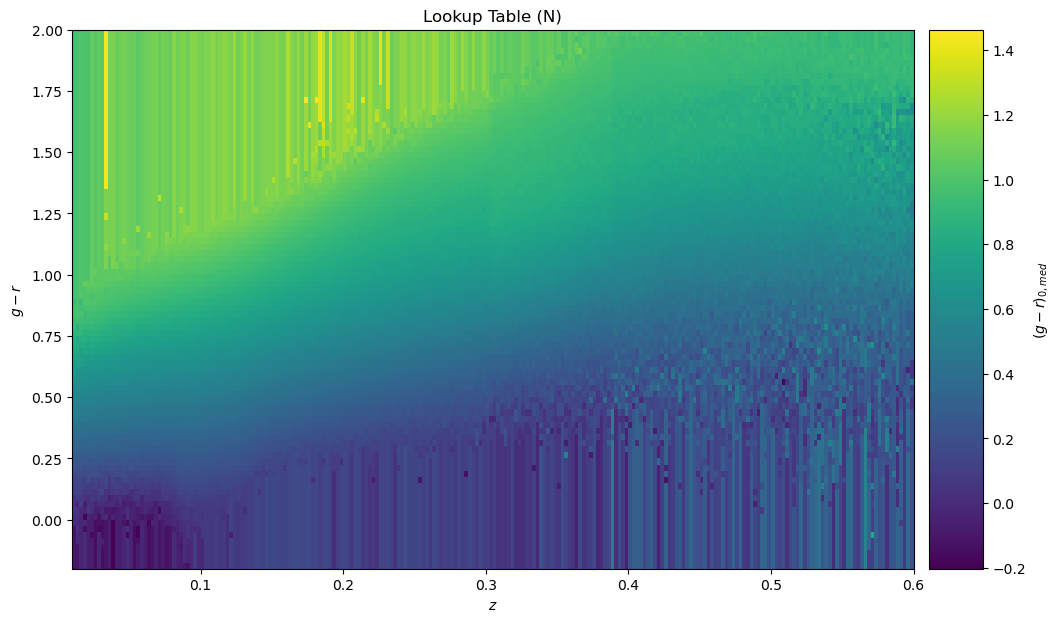

REST-FRAME COLOURS ASSIGNED.
Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
Computing restframe colours for region  N using lookup for region  N
using precomputed k-corrections
LOADING IN LOOKUP TABLE


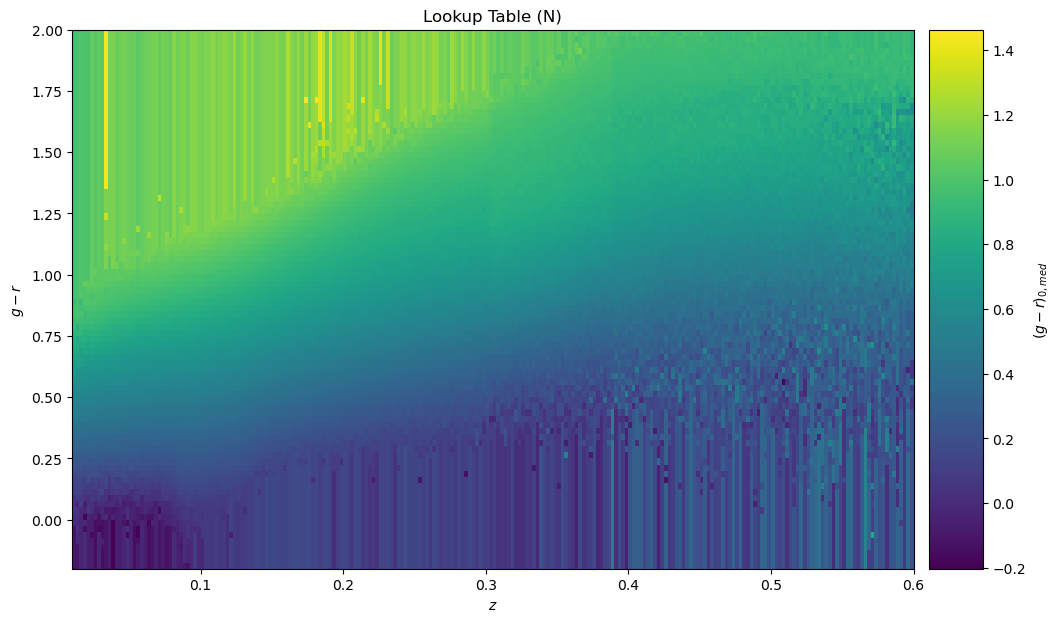

REST-FRAME COLOURS ASSIGNED.
Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
Statistics of the data catalogue after computing and adding rest frame colours and absolute magnitudes:
<Table length=367659>
       name           mean        std        min         max    
----------------- ----------- ----------- ---------- -----------
         TARGETID 5.27143e+06 3.00815e+06        132 1.04801e+07
           TILEID     23078.9     1827.33      20000       27852
  ABSMAG_RP1_ORIG    -20.2119      1.2038   -23.4295    -10.8985
REST_GMR_0P1_ORIG    0.721786    0.236318  -0.523583      1.6641
          gmr_obs    0.977848    0.392206  -0.502557     2.35777
              DEC     22.2941     23.1511   -19.2858      79.127
               RA     184.718     92.1816 0.00169094     359.996
                Z    0.205399   0.0977373 0.00222993    0.599254
            NTILE     2.41489      0.9172          1           5
              reg          --          --         --  

In [2]:
# If you want to recompute the colour lookup table and k-correction polynomials set fresh=True otherwise re-use stored table and fits
fresh = fresh_kcorr
plot= True
info= True
forceN = True  # Force use of N lookup and k-correction for all data

if (fresh == True) :
  print('Recomputing colour look-up and k-correction polynomials')
  # Read John Moustakas's Fast Spec Catalogue
  fsf=ca.read_fsf(fsffile)
  print('statistics of the Fast Spectral Fitting Catalogue used for k-correction')
  fsf.info('stats')
  ca.recompute_rest_col_mag(dat,regions,fsf,fresh=fresh,plot=plot,forceN=forceN)  
else:
  fsf='null' #just defining the variable so code doesn't complain  
  print('Using pre-computed colour look-up and k-correction polynomials')
  #compute rest frame colours and absolute magnitudes using k-corrections already computed from the fsf catalogue
  ca.recompute_rest_col_mag(dat,regions,fsf,fresh=False,plot=plot,forceN=forceN)

if (info):
   print('Statistics of the data catalogue after computing and adding rest frame colours and absolute magnitudes:')
   dat.info('stats')

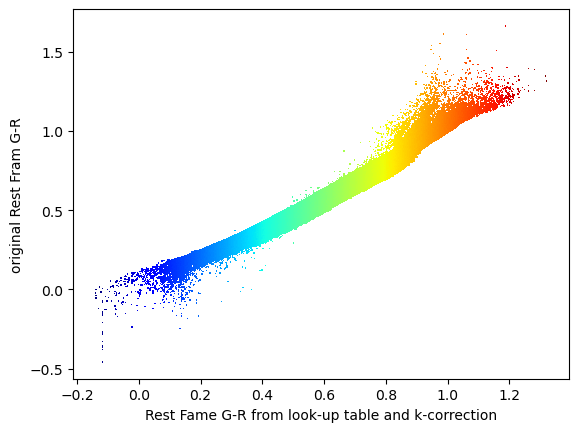

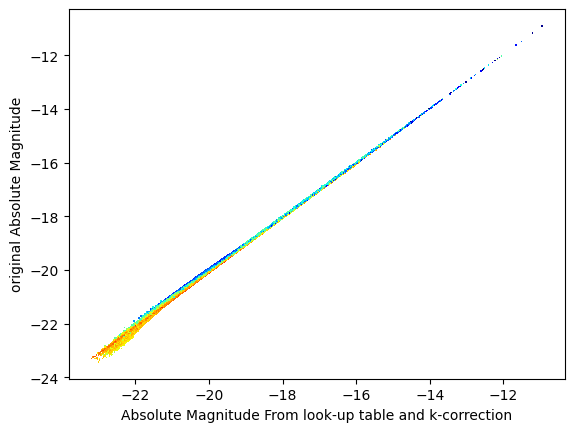

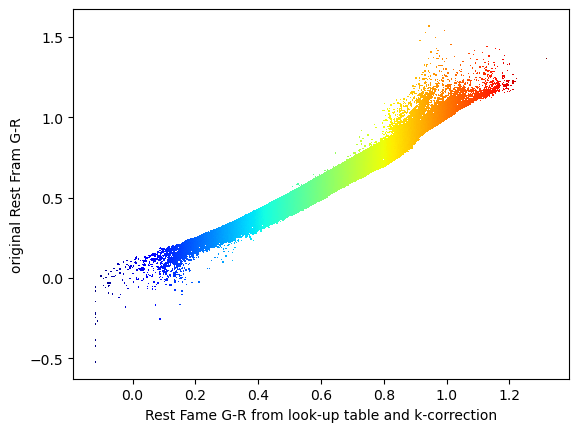

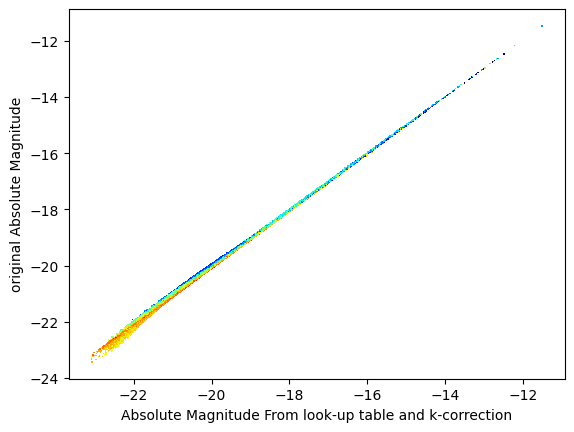

In [3]:
for reg in regions:
    mask=(dat["reg"]==reg)

    plt.scatter(dat['REST_GMR_0P1'][mask],dat['REST_GMR_0P1_ORIG'][mask],marker=',',lw=0,s=1.0,c=dat['REST_GMR_0P1'][mask],cmap='jet')
    plt.xlabel('Rest Fame G-R from look-up table and k-correction')
    plt.ylabel('original Rest Fram G-R')
    plt.show()

    plt.scatter(dat['ABSMAG_RP1'][mask],dat['ABSMAG_RP1_ORIG'][mask],marker=',',lw=0,s=1.0,c=dat['REST_GMR_0P1'][mask],cmap='jet')
    plt.xlabel('Absolute Magnitude From look-up table and k-correction')
    plt.ylabel('original Absolute Magnitude')
    plt.show()
    


Using healpix map with NSIDE=32 and pixel area 3.357 sq.deg.


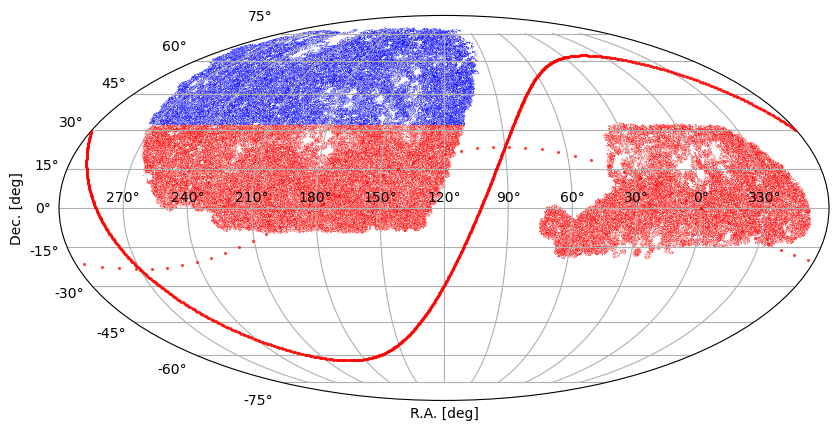

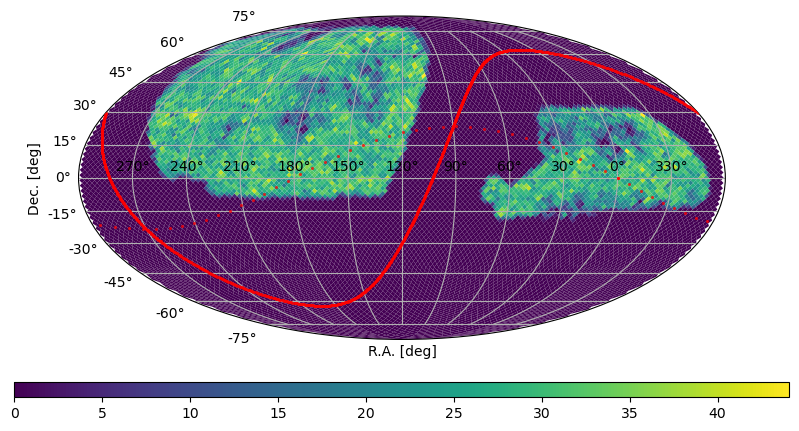

In [4]:

#sky plot
ca.sky_plot(dat,regions)


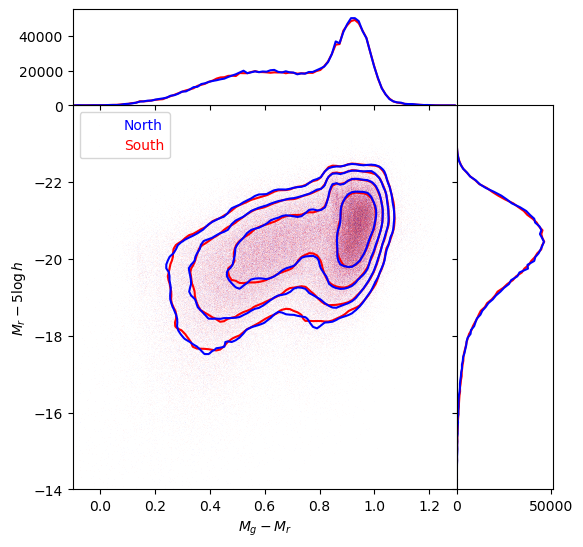

In [5]:
#colour-magnitude distributions
ca.plot_col_mag(dat,regions)


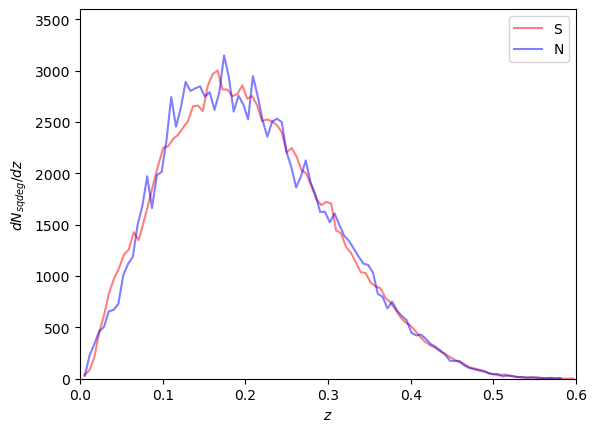

In [6]:
for reg in regions:
        Sel=ca.selection(reg) # define selection parameters for this region
        regmask = (dat['reg']==reg)
        weights=dat['WEIGHT']/Sel['f_ran']
        # A weighted histogram using the combined systematics and completeness weight  
        dndz,binz=np.histogram(dat['Z'][regmask], bins=100,  weights=weights[regmask])
        bin_cen=(binz[1:]+binz[:-1])/2.0
        dz=binz[1]-binz[0] #redshift bin width
        dndz= (dndz/dz)/(Sel['area']*(4*np.pi*(180.0/np.pi)**2))   # rescale by area in sq deg and bin width 
        plt.plot(bin_cen,dndz,color=Sel['col'],alpha=0.5,label=reg)    
plt.ylabel('$dN_{sq deg}/dz$')        
plt.xlabel('$z$')        
plt.xlim(0.0,0.6) 
plt.ylim(0.0,3600.0)
plt.legend()
plt.show()        


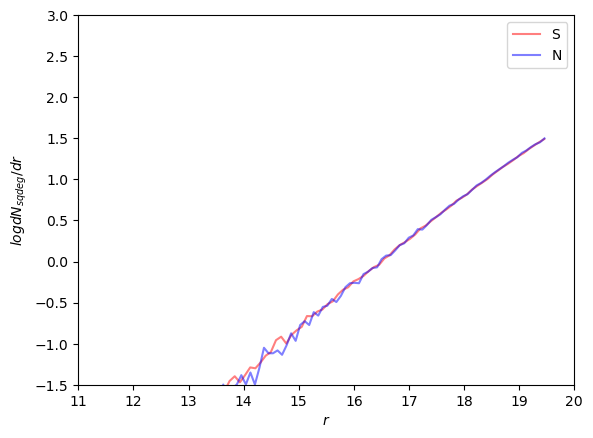

In [7]:
#Plot number counts
for reg in regions:
        Sel=ca.selection(reg) # define selection parameters for this region
        regmask = (dat['reg']==reg)
        weights=dat['WEIGHT']/Sel['f_ran']
        # A weighted histogram using the combined systematics and completeness weight  
        dn,bin=np.histogram(dat['rmag'][regmask], bins=100)
        bin_cen=(bin[1:]+bin[:-1])/2.0
        dm=bin[1]-bin[0] #bin width
        dndm= (dn/dm)/(Sel['area']*(4*np.pi*(180.0/np.pi)**2))   # rescale by area in sq deg and bin width 
        plt.plot(bin_cen,np.log10(dndm+1.0e-20),color=Sel['col'],alpha=0.5,label=reg)
plt.ylabel('$log dN_{sq deg}/dr$')        
plt.xlabel('$r$')        
plt.xlim(11,20) 
plt.ylim(-1.5,3.0)
plt.legend()
plt.show()    

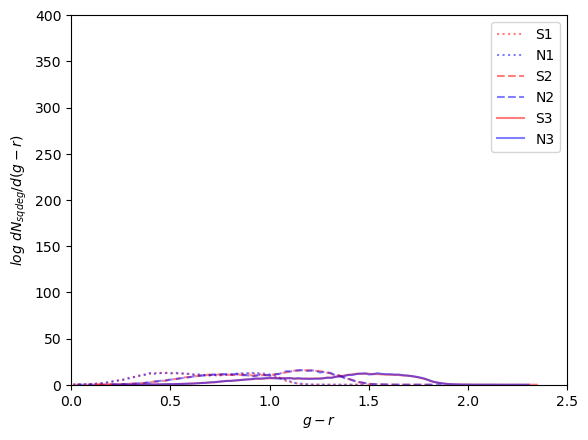

In [8]:
#plot oberver frame g-r colour distribution in redshift bins
for slice in (1,2,3):
    if (slice==1): 
        zmin=0
        zmax=0.15
        ltype='dotted'
    if (slice==2): 
        zmin=0.15
        zmax=0.25
        ltype='dashed'
    if (slice==3): 
        zmin=0.25
        zmax=0.5
        ltype='solid'
    for reg in regions:
        Sel=ca.selection(reg) # define selection parameters for this region
        regmask = (dat['reg']==reg) & (dat['gmr_obs']>0.0) & (dat['gmr_obs']<2.5)  & (dat['Z']>zmin) & (dat['Z']<zmax)
        weights=dat['WEIGHT']/Sel['f_ran']
        # A weighted histogram using the combined systematics and completeness weight  
        dn,bin=np.histogram((dat['gmr_obs'][regmask]), bins=100)
        bin_cen=(bin[1:]+bin[:-1])/2.0
        dcol=bin[1]-bin[0] #bin width
        dndcol= (dn/dcol)/(Sel['area']*(4*np.pi*(180.0/np.pi)**2))   # rescale by area in sq deg and bin width 
        plt.plot(bin_cen,(dndcol),color=Sel['col'],alpha=0.5,label=reg+str(slice),linestyle=ltype)
plt.ylabel('$log\ dN_{sq deg}/d(g-r)$')        
plt.xlabel('$g-r$')        
plt.xlim(0.0,2.5) 
plt.ylim(0,400)
plt.legend()
plt.show()

starting region  S
Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
Sample size in this region and between faint and bright apparent magnitude limits: 253033
This is the right thing to do when zmax computed from the faint limit is greater than the zmax imposed in the sample selection
Similary it is the right thing to if zmin computed from the bright limit is less than the zmin imposed in the sample selection
root_itp2: maximum number of iterations required= 18
iteration 1 : 252940  not yet converged
iteration 2 : 252940  not yet converged
iteration 3 : 252862  not yet converged
iteration 4 : 228733  not yet converged
iteration 5 : 117724  not yet converged
iteration 6 : 59285  not yet converged
iteration 7 : 45725  not yet converged
iteration 8 : 42717  not yet converged
iteration 9 : 41476  not yet converged
iteration 10 : 40953  not yet converged
iteration 11 : 40664  not yet converged
iteration 12 : 40425  not yet converged
iteration 13 : 39836  not yet co

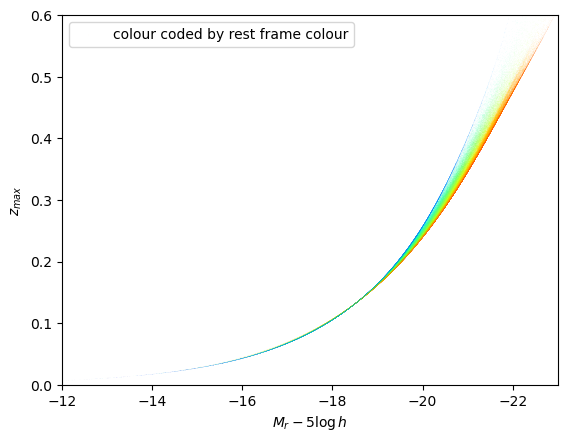

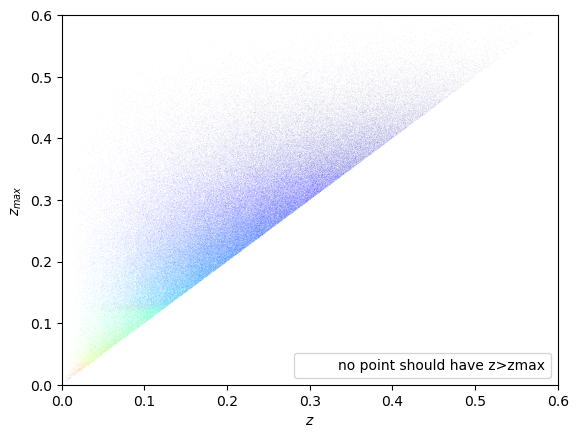

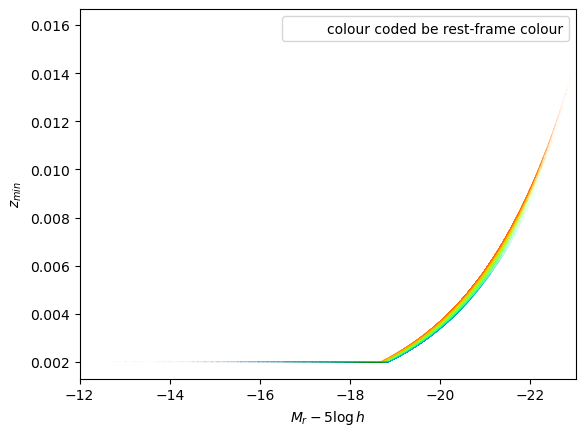

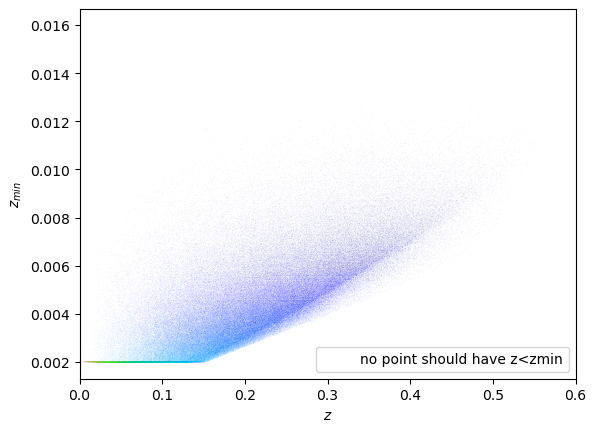

In [9]:
# Compute zmax and vmax values
ca.compute_zmax_vmax(dat,regions,forceN=True)
#  

if plot:    
    # Make some test plots but avoid plotting data from any unprocessed region
    if (len(regions) > 1):
       regmask=  ((dat['reg']=='N') | (dat['reg']=='S'))
    else:    
       regmask= (dat['reg']==regions)
    #Plots of how zmax depends on absolute magnitude, colour and redshift
    ca.plot_zmax_absmag(dat[regmask])
    ca.plot_zmax_z(dat[regmask])
    #Plots of how zmin depends on absolute magnitude, colour and redshift
    ca.plot_zmin_absmag(dat)
    ca.plot_zmin_z(dat[regmask])

In [10]:
# Write the Augmented table to a fits file 
# Add meta data to store the selection cuts used in defining this sample and other information
Sel=ca.selection('N')
dat.meta['Qevol_N']=Sel['Qevol']
dat.meta['zmax_N']=Sel['zmax']
dat.meta['zmin_N']=Sel['zmin']
dat.meta['bright_N']=Sel['bright']
dat.meta['faint_N']=Sel['faint']
dat.meta['area_N']=Sel['area']
dat.meta['f_ran_N']=Sel['f_ran']
dat.meta['col_N']=Sel['col']
dat.meta['style_N']=Sel['style']

Sel=ca.selection('S')
dat.meta['Qevol_S']=Sel['Qevol']
dat.meta['zmax_S']=Sel['zmax']
dat.meta['zmin_S']=Sel['zmin']
dat.meta['bright_S']=Sel['bright']
dat.meta['faint_S']=Sel['faint']
dat.meta['area_S']=Sel['area']
dat.meta['f_ran_S']=Sel['f_ran']
dat.meta['col_S']=Sel['col']
dat.meta['style_S']=Sel['style']
#
# Store the parameters of the cosmology used to make this catalogue
dat.meta['H0']=ca.cosmo.H0.value
dat.meta['Tcmb0']=ca.cosmo.Tcmb0.value
dat.meta['Om0']=ca.cosmo.Om0
#

# Write the table complete with its meta data
#
dat.write('sdata/BGS_mockY3_Oct2025.fits',overwrite=True) 
